# Quantum Algorithmic Foundations — Simple Learning Notebook

**Learn → Run → Change → Practice**

## What you will learn

1. Integer factorization and GCD
2. Binary encodings and input length
3. Circuit size and circuit depth
4. Big-O notation and computational cost
5. Polynomial vs exponential cost
6. Toffoli, NOT, AND, OR, and FANOUT ideas
7. Simulating classical computations with Qiskit
8. Garbage and **compute → copy → uncompute**
9. Modular exponentiation

## 0. Setup

Only a few imports are needed.

If Qiskit or SymPy is missing in a fresh environment, uncomment the installation line first.

In [15]:
# Uncomment only if you need to install the packages.
# %pip install -q qiskit sympy

import math
from sympy.ntheory import factorint

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector

print("Ready.")

Ready.


# 1. Integer factorization and GCD

## Integer factorization

**Input:** an integer \(N \ge 2\)  
**Output:** the prime factorization of \(N\)

Example:

\[
12 = 2^2 \cdot 3
\]

Prime factorization is unique, apart from the ordering of the factors.

In [16]:
# Small factoring examples

print("12  ->", factorint(12))
print("91  ->", factorint(91))
print("360 ->", factorint(360))

12  -> {2: 2, 3: 1}
91  -> {7: 1, 13: 1}
360 -> {2: 3, 3: 2, 5: 1}


## Greatest common divisor

**Input:** nonnegative integers N and M, not both zero  
**Output:** the largest integer that divides both numbers.

Euclid's algorithm repeatedly replaces

$$
(a,b)
$$

with

$$
(b,\; a \bmod b).
$$

In [17]:
# Euclid's algorithm

a = 252
b = 105
# try to practice the steps of Euclid's algorithm by hand first, then go through the steps in code.
while b != 0:
    print(a, "=", a // b, "*", b, "+", a % b)
    a, b = b, a % b

print("GCD =", a)

252 = 2 * 105 + 42
105 = 2 * 42 + 21
42 = 2 * 21 + 0
GCD = 21


#### Common symbols used
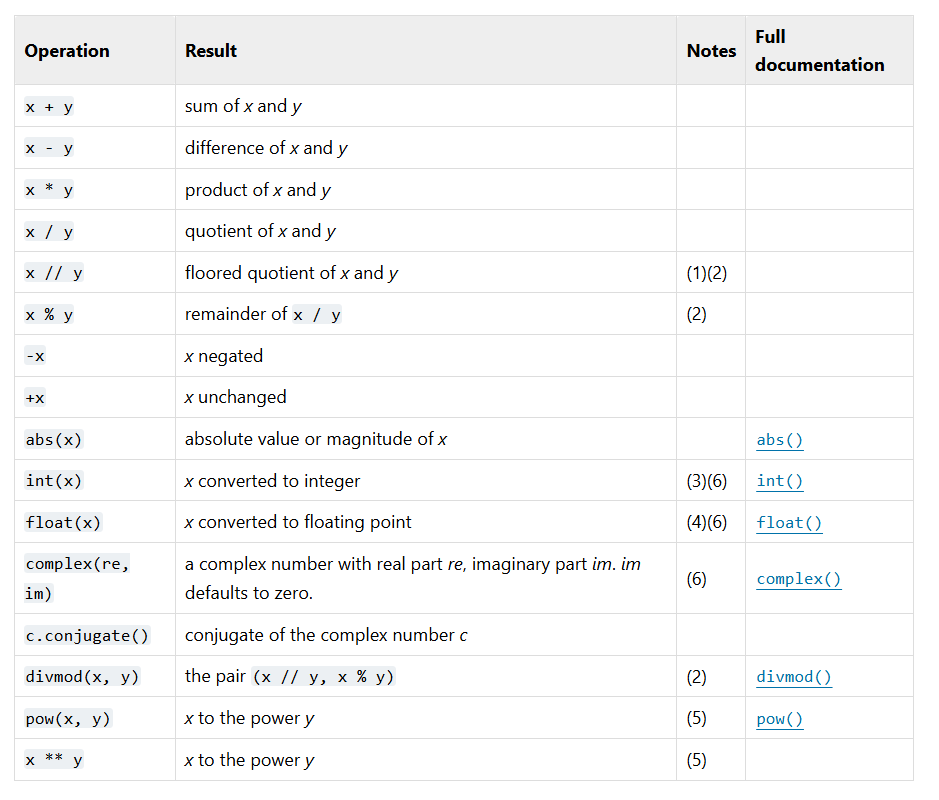
Source: https://docs.python.org/3/library/stdtypes.html#index-13

### Practice 1 — GCD

Change the two numbers below and run Euclid's algorithm.

In [18]:
a = 662
b = 414
# TODO:
# Try to fill the missing part of the simple Euclid loop .
while b != 0 :
    print(a, '=', a // b , '*', b, '+', a % b)
    break # Remove this line when you fill in the missing part of the loop.
# Print the final GCD.
print ("GCD =", a)


662 = 1 * 414 + 248
GCD = 662


# 2. Computation, encodings, and input length
Inputs and outputs are treated as **binary strings**.

Binary strings can encode numbers, vectors, matrices, graphs, molecules, and many other objects.

For a nonnegative integer \(N\), the binary input length is

$$
\operatorname{lg}(N)=
\begin{cases}
1,&N=0\\
1+\lfloor\log_2N\rfloor,&N\ge1.
\end{cases}
$$

The important idea is:

> **Computational cost is studied as a function of input length, not simply the numerical value of the input.**

In [19]:
# Binary encoding and input length
# just given here as an example of how to compute the length of a binary encoding of an integer N.Do not worry about the details of this code.
for N in range(13):
    binary = bin(N)[2:]
    length = max(1, N.bit_length())
    print(N, "->", binary, "->", length, "bit(s)")

0 -> 0 -> 1 bit(s)
1 -> 1 -> 1 bit(s)
2 -> 10 -> 2 bit(s)
3 -> 11 -> 2 bit(s)
4 -> 100 -> 3 bit(s)
5 -> 101 -> 3 bit(s)
6 -> 110 -> 3 bit(s)
7 -> 111 -> 3 bit(s)
8 -> 1000 -> 4 bit(s)
9 -> 1001 -> 4 bit(s)
10 -> 1010 -> 4 bit(s)
11 -> 1011 -> 4 bit(s)
12 -> 1100 -> 4 bit(s)


### Practice 2 — Think in bits

Without running Python first, predict the bit lengths of:

- \(15\)
- \(16\)
- \(31\)
- \(32\)
- \(2^{100}\)

Then use the cell below to check.

In [20]:
numbers = [15, 16, 31, 32, 2**100]

for N in numbers:
    print(N, "uses", N.bit_length(), "bits")

15 uses 4 bits
16 uses 5 bits
31 uses 5 bits
32 uses 6 bits
1267650600228229401496703205376 uses 101 bits


# 3. Elementary operations, circuit size, and depth

For circuit-based computation, gates are treated as **elementary operations**.

The slides use a standard Boolean gate set:

- AND
- OR
- NOT
- FANOUT

For quantum circuits, the lesson discusses single-qubit gates such as \(X,Y,Z,H,S,T\), controlled-NOT, measurements, and decompositions into elementary gates.

## Circuit size

The **size** of a circuit is the total number of gates.

It corresponds to **sequential computational cost** in this lesson.

## Circuit depth

The **depth** is the maximum number of gates along a dependency path.

It corresponds to **parallel running time**.

In [23]:
# A small Qiskit circuit

qc = QuantumCircuit(4)

qc.h(0)
qc.x(1)
qc.cx(0, 2)
qc.t(2)
qc.cx(1, 3)
qc.z(3)

print(qc.draw(output='text'))
print("size  =", qc.size())
print("depth =", qc.depth())
print("operations =", qc.count_ops())

     ┌───┐               
q_0: ┤ H ├──■────────────
     ├───┤  │            
q_1: ┤ X ├──┼────■───────
     └───┘┌─┴─┐  │  ┌───┐
q_2: ─────┤ X ├──┼──┤ T ├
          └───┘┌─┴─┐├───┤
q_3: ──────────┤ X ├┤ Z ├
               └───┘└───┘
size  = 6
depth = 3
operations = OrderedDict([('cx', 2), ('h', 1), ('x', 1), ('t', 1), ('z', 1)])


### Practice 3 — Same number of gates, different depth

Create two 4-qubit circuits.

**Circuit A:** place four \(X\) gates one after another on qubit 0.  
**Circuit B:** place one \(X\) gate on each of the four different qubits.

Both circuits have the same number of gates, but their depths are different.

In [30]:
serial = QuantumCircuit(4)
parallel = QuantumCircuit(4)

# TODO — Circuit A
# serial.x(0)
# ...

# TODO — Circuit B
# parallel.x(0)
# parallel.x(1)
# ...

print("serial:   size =", serial.size(), "depth =", serial.depth())
print("parallel: size =", parallel.size(), "depth =", parallel.depth())

serial:   size = 0 depth = 0
parallel: size = 0 depth = 0


# 4. Cost as a function of input length

A single circuit has a fixed size. To describe an algorithm for different input lengths, we use a **family of circuits**

$$
\{C_1,C_2,C_3,\ldots\}.
$$

If \(C_n\) handles inputs of length \(n\), then the cost can be written as

$t(n)=\operatorname{size}(C_n)$

## Big-O notation

We write

$$g(n)=O(h(n))
$$
when \(g(n)\) eventually grows no faster than a constant multiple of \(h(n)\).

The lesson gives these useful cost examples:

| Computation | Cost stated in the lesson |
|---|---:|
| Addition | $O(n)$ |
| Standard multiplication | \($O(n^2)$\) |
| Standard division | \($O(n^2)$\) |
| GCD | \($O(n^2)$\) for equal \(n\)-bit inputs |
| Modular exponentiation | \($O(n^3)$\) for equal \(n\)-bit inputs |
| Simple trial-division factoring | \($O(n^2 2^{n/2})$\) |

In [32]:
# Compare a few growth rates numerically, just analyse how they grow as n increases. This is just to give you a feel for the growth rates, and to help you understand the big-O notation.

for n in [4, 8, 16, 32]:
    print(
        "n =", n,
        "| n =", n,
        "| n^2 =", n**2,
        "| n^3 =", n**3,
        "| 2^(n/2) =", int(2**(n/2))
    )

n = 4 | n = 4 | n^2 = 16 | n^3 = 64 | 2^(n/2) = 4
n = 8 | n = 8 | n^2 = 64 | n^3 = 512 | 2^(n/2) = 16
n = 16 | n = 16 | n^2 = 256 | n^3 = 4096 | 2^(n/2) = 256
n = 32 | n = 32 | n^2 = 1024 | n^3 = 32768 | 2^(n/2) = 65536


## Polynomial vs exponential cost

A cost is called **polynomial** in the lesson when it is $O(n^b)$ for some fixed constant $b>0$.

Addition, multiplication, division, GCD, and modular exponentiation are examples of polynomial-cost computations in the lesson.

- no sub-exponential-cost classical factoring algorithm is known;
- Shor's algorithm gives a polynomial-cost **quantum** algorithm for integer factorization.

Polynomial cost is used as a first approximation of efficiency, although it does not automatically mean that an implementation is practical.

### Practice 4 — Cost classification

Classify each expression as **polynomial** or **not polynomial** in \(n\):

1. \(n\)
2. \($n^2$\)
3. \($n^3$\)
4. \($2^{n/2}$\)
5. \($n^{10}$\)

Write your answers below before continuing.

In [34]:
# Write your answers as strings.putthe answers in the "".

answers = {
    "n": "",
    "n^2": "",
    "n^3": "",
    "2^(n/2)": "",
    "n^10": "",
}

answers

{'n': '', 'n^2': '', 'n^3': '', '2^(n/2)': '', 'n^10': ''}

# 5. Toffoli gates and classical logic in Qiskit

A **Toffoli gate** is a controlled-controlled-NOT gate.

On computational-basis bits,

$$|a,b,c\rangle
\longmapsto
|a,b,c\oplus ab\rangle$$

If the target begins in $|0\rangle$, the target becomes

$$a\land b$$

This makes the Toffoli gate a natural building block for simulating classical AND logic.

In [35]:
# AND example: a = 1, b = 1
# q2 starts at 0 and becomes a AND b.

qc = QuantumCircuit(3)

qc.x(0)          # a = 1
qc.x(1)          # b = 1
qc.ccx(0, 1, 2)  # q2 = a AND b

print(qc.draw(output="text"))

state = Statevector.from_instruction(qc)
print("Final basis-state probabilities:")
print(state.probabilities_dict())

     ┌───┐     
q_0: ┤ X ├──■──
     ├───┤  │  
q_1: ┤ X ├──■──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘
Final basis-state probabilities:
{np.str_('111'): np.float64(1.0)}


## FANOUT with CNOT

For classical basis-state data, a controlled-NOT can simulate FANOUT:
$$
|a,0\rangle \longmapsto |a,a\rangle.
$$
This is a simulation of classical FANOUT on basis states. It is **not** a general machine for cloning arbitrary unknown quantum states.

In [36]:
# FANOUT example: a = 1

qc = QuantumCircuit(2)

qc.x(0)       # a = 1
qc.cx(0, 1)   # copy the classical basis value to q1

print(qc.draw(output="text"))
print(Statevector.from_instruction(qc).probabilities_dict())

     ┌───┐     
q_0: ┤ X ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
{np.str_('11'): np.float64(1.0)}


## OR from NOT and Toffoli

The slides show that AND and OR can be built using Toffoli and NOT gates.

Using De Morgan's rule,

$$a\lor b = \neg(\neg a\land \neg b)$$

The next cell follows that idea directly.

In [37]:
# OR example: a = 1, b = 0

qc = QuantumCircuit(3)

qc.x(0)       # a = 1
# q1 stays 0  # b = 0

qc.x(0)       # NOT a
qc.x(1)       # NOT b
qc.ccx(0, 1, 2)
qc.x(2)       # NOT((NOT a) AND (NOT b))

print(qc.draw(output="text"))
print(Statevector.from_instruction(qc).probabilities_dict())

# q2 contains a OR b.

     ┌───┐┌───┐          
q_0: ┤ X ├┤ X ├──■───────
     ├───┤└───┘  │       
q_1: ┤ X ├───────■───────
     └───┘     ┌─┴─┐┌───┐
q_2: ──────────┤ X ├┤ X ├
               └───┘└───┘
{np.str_('110'): np.float64(1.0)}


### Practice 5 — Test the truth tables

For both the AND and OR examples:

1. try \(a,b=0,0\);
2. try \(0,1\);
3. try \(1,0\);
4. try \(1,1\).

Change only the input \(X\) gates. Record the output qubit each time.

In [38]:
# Practice area — build one AND test here.

qc = QuantumCircuit(3)

# Choose a and b by adding X gates to q0 and/or q1.
# qc.x(0)
# qc.x(1)

qc.ccx(0, 1, 2)

print(qc.draw(output="text"))
print(Statevector.from_instruction(qc).probabilities_dict())

          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
{np.str_('000'): np.float64(1.0)}


# 6. Simulating a Boolean circuit and cleaning garbage

Suppose a Boolean circuit \(C\) has \(t\) gates.

The lesson explains that its AND, OR, NOT, and FANOUT operations can be replaced by reversible quantum simulations with **\(O(t)\)** gates.

However, intermediate workspace values can remain behind. The slides call these values **garbage**.

Garbage can interfere with later quantum interference, so a useful quantum subroutine should clean it.

The central pattern is:


$$\boxed{\text{compute} \rightarrow \text{copy useful output} \rightarrow \text{uncompute}}
$$
The next example shows the entire idea with only three gates.

In [39]:
# Clean AND example
#
# q0 = a
# q1 = b
# q2 = workspace
# q3 = clean output

qc = QuantumCircuit(4)

qc.x(0)            # a = 1
qc.x(1)            # b = 1

qc.ccx(0, 1, 2)    # COMPUTE: q2 = a AND b
qc.cx(2, 3)        # COPY:    copy useful result to q3
qc.ccx(0, 1, 2)    # UNCOMPUTE: return q2 to 0

print(qc.draw(output="text"))
print(Statevector.from_instruction(qc).probabilities_dict())

print("size  =", qc.size())
print("depth =", qc.depth())

     ┌───┐               
q_0: ┤ X ├──■─────────■──
     ├───┤  │         │  
q_1: ┤ X ├──■─────────■──
     └───┘┌─┴─┐     ┌─┴─┐
q_2: ─────┤ X ├──■──┤ X ├
          └───┘┌─┴─┐└───┘
q_3: ──────────┤ X ├─────
               └───┘     
{np.str_('1011'): np.float64(1.0)}
size  = 5
depth = 4


### Why the previous cell matters

At the end:

- the input bits are preserved;
- the workspace qubit is back to \(0\);
- the useful answer remains in the output qubit.

That is the clean reversible-computation pattern used in the slides.

### Practice 6 — Clean AND for every input

Change the input \(X\) gates in the previous circuit and test all four values of \(a,b\).

For every input, check that:

- q2 returns to \(0\);
- q3 contains \(a\land b\).

Then try adding an \(X\) gate to q3 after the COPY step to turn the clean output into NAND.

# 7. Modular exponentiation

The lesson defines modular exponentiation as


$$ N^K \pmod M $$

It explains that we should not first build the enormous number \($N^K$\) and only then reduce it modulo \(M\).

Instead, the **binary method / repeated squaring** uses the binary representation of the exponent and performs the calculation modulo \(M\) throughout.

For equal \(n\)-bit inputs, the lesson gives an \($O(n^3)$\) cost.

In [40]:
# Python already provides efficient modular exponentiation.

N = 7
K = 181
M = 55

print("7^181 mod 55 =", pow(N, K, M))
print("binary K =", bin(K))
print("bit length of K =", K.bit_length())

7^181 mod 55 = 7
binary K = 0b10110101
bit length of K = 8


## Repeated squaring, written directly

This cell shows the basic idea without wrapping it in a function.

In [42]:
base = 5
exponent = 13
modulus = 19
result = 1

print("exponent in binary:", bin(exponent))

while exponent > 0:
    print("exponent =", exponent, "| result =", result, "| base =", base)

    if exponent % 2 == 1:
        result = (result * base) % modulus

    base = (base * base) % modulus
    exponent = exponent // 2

print("answer =", result)

exponent in binary: 0b1101
exponent = 13 | result = 1 | base = 5
exponent = 6 | result = 5 | base = 6
exponent = 3 | result = 5 | base = 17
exponent = 1 | result = 9 | base = 4
answer = 17


### Practice 7 — Modular exponentiation

Repeat the previous calculation for

$$7^{23}\pmod{15}.$$

Then compare your answer with:

```python
pow(7, 23, 15)
```

Notice how the exponent is repeatedly divided by 2.

In [ ]:
# TODO: repeat the direct repeated-squaring steps here.

print("Python check:", pow(7, 23, 15))

# 8. Why trial-division factoring becomes expensive

A simple factoring method tests possible divisors up to approximately

$$\sqrt N
$$
If \(N\) has \(n\) bits, then \(N\) can be roughly as large as \(2^n\), so

$$\sqrt N \approx 2^{n/2}$$

This is why the lesson gives simple trial division a cost of

$$
O(n^2 2^{n/2})
$$

The exponential term is the important contrast with the polynomial costs of GCD and modular exponentiation.

In [43]:
# Simple trial division written directly

N = 91
divisor = 2
factor = None
tests = 0

while divisor * divisor <= N:
    tests += 1

    if N % divisor == 0:
        factor = divisor
        break

    divisor += 1

if factor is None:
    print(N, "is prime")
else:
    print("A factor of", N, "is", factor)

print("divisibility tests =", tests)
print("input length =", N.bit_length(), "bits")

A factor of 91 is 7
divisibility tests = 6
input length = 7 bits


### Practice 8 — Compare factoring examples

Change \(N\) and compare the number of divisibility tests.

Try:

- 91
- 221
- 899
- 1763

For each number, record:

1. its bit length;
2. the first factor found;
3. the number of divisibility tests.

Then explain why two numbers with similar bit lengths can still take different amounts of time in this simple algorithm.

In [ ]:
# Practice area

N = 221

# Copy the simple trial-division code from the previous cell here
# and record your result.

# 9. One-page concept map inside the notebook

## The complete story

**1. Encode the input**  
Computations are studied using binary strings. Input length is measured in bits.

**2. Choose elementary operations**  
For circuits, gates are the elementary operations.

**3. Measure cost**  
Circuit **size** measures total gate count; circuit **depth** reflects parallel layers.

**4. Study scaling**  
A family $C_n$ describes how the circuit changes as the input length \(n\) grows.

**5. Use Big-O notation**  
Big-O keeps attention on the main growth rate.

**6. Classical arithmetic examples from the lesson**

- addition: $O(n)$
- multiplication: $O(n^2)$
- division: $O(n^2)$
- GCD: $O(n^2)$
- modular exponentiation: $O(n^3)$

**7. Factoring is the contrast**  
Simple trial division contains an exponential-style $2^{n/2}$ factor.

**8. Quantum circuits can simulate classical circuits**  
NOT, CNOT, and Toffoli are enough for the Boolean-gate simulations discussed in the lesson.

**9. Reversibility creates workspace**  
Intermediate information may remain as garbage.

**10. Clean it**  
Use **compute → copy → uncompute**.

That chain of ideas is the algorithmic foundation needed before studying later quantum algorithms such as Shor's algorithm.

# Final self-check

You should now be able to answer these without looking back:

1. What is integer factorization?
2. What is a GCD?
3. How does Euclid's algorithm reduce the problem?
4. Why do we measure integer input size in bits?
5. What is circuit size?
6. What is circuit depth?
7. What does \(O(n^2)\) tell us?
8. Which arithmetic tasks in this lesson have polynomial cost?
9. Why does simple trial division become expensive as bit length grows?
10. What does a Toffoli gate do?
11. How does a Toffoli gate simulate AND?
12. How does CNOT simulate classical FANOUT?
13. What is garbage in a reversible computation?
14. Explain **compute → copy → uncompute**.